In [1]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("GOOGL.csv")
df

,Date,Open,High,Low,Close,Adj Close,Volume
0,2004-08-19,50.050049,52.082081,48.028027,50.220219,50.220219,44659096
1,2004-08-20,50.555557,54.594597,50.300301,54.209209,54.209209,22834343
2,2004-08-23,55.430431,56.796799,54.579578,54.754753,54.754753,18256126
3,2004-08-24,55.675674,55.855858,51.836838,52.487488,52.487488,15247337
4,2004-08-25,52.532532,54.054054,51.991993,53.053055,53.053055,9188602
...,...,...,...,...,...,...,...
4426,2022-03-18,2668.489990,2724.879883,2645.169922,2722.510010,2722.510010,2223100
4427,2022-03-21,2723.270020,2741.000000,2681.850098,2722.030029,2722.030029,1341600
4428,2022-03-22,2722.030029,2821.000000,2722.030029,2797.360107,2797.360107,1774800
4429,2022-03-23,2774.050049,2791.770020,2756.699951,2765.510010,2765.510010,1257700


In [3]:
display(df.shape)
df.dropna()
display(df.shape)

(4431, 7)

(4431, 7)

In [4]:
training_set = df[['Open']]
scaler = MinMaxScaler()
training_set_scaled = scaler.fit_transform(training_set)
training_set_scaled

array([[1.36253641e-04],
       [3.06152003e-04],
       [1.94456941e-03],
       ...,
       [8.98173517e-01],
       [9.15657150e-01],
       [9.19001272e-01]], shape=(4431, 1))

In [5]:
X_train = []
X_test =[]
y_train = []
y_test = []

for i in range(60, len(training_set_scaled)-320):
    X_train.append(training_set_scaled[i-60:i, 0])
    y_train.append(training_set_scaled[i, 0])

for i in range(len(training_set_scaled)-320, len(training_set_scaled)):
    X_test.append(training_set_scaled[i-60:i, 0])
    y_test.append(training_set_scaled[i, 0])

X_train = np.array(X_train)
X_test = np.array(X_test)
y_train = np.array(y_train)
y_test = np.array(y_test)

In [6]:
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))

In [7]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import Dense

model = Sequential()
model.add(LSTM(units=50, return_sequences=True, input_shape = (X_train.shape[1], 1)))
model.add(Dropout(0.2))
model.add(LSTM(units=50, return_sequences=False))
model.add(Dropout(0.2))
model.add(Dense(units=1))

E:\Avdhoot\GitHub\AG1713\Practicals\LP3\ML\venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [8]:
model.compile(
    optimizer='adam',
    loss='mean_squared_error'
)

In [9]:
model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32
)

Epoch 1/20
127/127 ━━━━━━━━━━━━━━━━━━━━ 9s 42ms/step - loss: 0.0015
Epoch 2/20
127/127 ━━━━━━━━━━━━━━━━━━━━ 5s 41ms/step - loss: 4.9277e-04
Epoch 3/20
127/127 ━━━━━━━━━━━━━━━━━━━━ 10s 41ms/step - loss: 4.1437e-04
Epoch 4/20
127/127 ━━━━━━━━━━━━━━━━━━━━ 10s 41ms/step - loss: 4.0100e-04
Epoch 5/20
127/127 ━━━━━━━━━━━━━━━━━━━━ 6s 45ms/step - loss: 3.9110e-04
Epoch 6/20
127/127 ━━━━━━━━━━━━━━━━━━━━ 5s 41ms/step - loss: 3.4056e-04
Epoch 7/20
127/127 ━━━━━━━━━━━━━━━━━━━━ 10s 42ms/step - loss: 2.9567e-04
Epoch 8/20
127/127 ━━━━━━━━━━━━━━━━━━━━ 13s 62ms/step - loss: 2.9348e-04
Epoch 9/20
127/127 ━━━━━━━━━━━━━━━━━━━━ 11s 64ms/step - loss: 2.8653e-04
Epoch 10/20
127/127 ━━━━━━━━━━━━━━━━━━━━ 7s 55ms/step - loss: 2.7465e-04
Epoch 11/20
127/127 ━━━━━━━━━━━━━━━━━━━━ 6s 46ms/step - loss: 2.4457e-04
Epoch 12/20
127/127 ━━━━━━━━━━━━━━━━━━━━ 13s 65ms/step - loss: 2.2651e-04
Epoch 13/20
127/127 ━━━━━━━━━━━━━━━━━━━━ 11s 70ms/step - loss: 2.0123e-04
Epoch 14/20
127/127 ━━━━━━━━━━━━━━━━━━━━ 10s 65ms/step - 

In [10]:
y_pred = model.predict(X_test)

10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step


In [11]:
real_predictions = scaler.inverse_transform(y_pred)
real_actuals = scaler.inverse_transform(y_test.reshape(-1, 1))

print(f"Predicted Price: ${real_predictions[2][0]}")
print(f"Actual Price: ${real_actuals[2][0]}")
print(f"Difference: ${real_predictions[2][0] - real_actuals[2][0]}")

Predicted Price: $1747.5535888671875
Actual Price: $1746.170044
Difference: $1.3835448671875383


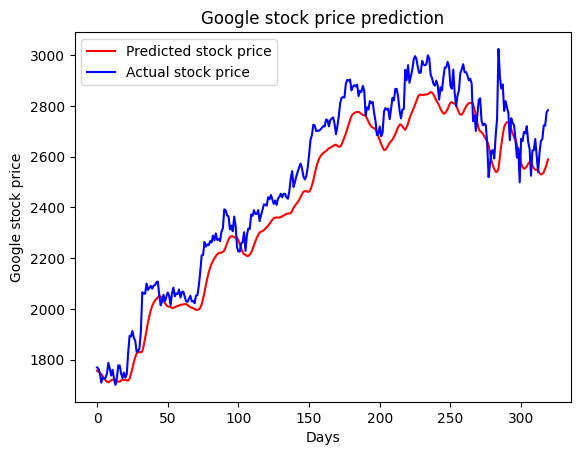

In [12]:
plt.plot(
    real_predictions,
    color='red',
    label='Predicted stock price'
)
plt.plot(
    real_actuals,
    color='blue',
    label='Actual stock price'
)
plt.title('Google stock price prediction')
plt.xlabel('Days')
plt.ylabel('Google stock price')
plt.legend()
plt.show()